# ESP32 Data Logger — Notebook Starter

This notebook loads one or more CSV log files, normalizes timestamps, and gives you a few utilities for smoothing, resampling, and basic calibration.

> Tip: Run all cells once, then tweak the **Config** section and rerun as needed.

## Setup

In [3]:

# === Setup ===
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from logger_tools import ensure_datetime_index, resample_df, ema, moving_average, LinearCal, segment_by_marks

# Display options
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


## Config

In [4]:

# === Config ===
# Point these at your logs. Example filenames: 2025-09-14_ride1.csv, 1694680995123.csv, etc.
DATA_DIR = r"C:\Users\benco\OneDrive\Documents\Arduino\esp32_data_logger\logs"  # change to your folder
GLOB = "2025-10-12_10-09-14_Slot machine.CSV"           # pattern for your logger files
LOCAL_TZ = "Australia/Perth"  # convert from UTC to your local time (optional)

# Choose your default resample rate for visualization (Hz). Set to None to skip.
RESAMPLE_HZ = 500

# Columns you'd like to plot by default (edit to match your sensors).
DEFAULT_PLOT_COLS = [
     "front_shock_mm_norm",
     "rear_shock_mm_norm",
    # "pot_raw", 
]

HIST_COLS = [
     "front_shock_mm_norm",
     "rear_shock_mm_norm",
    # "pot_raw", 
]

HIST_COLS_VEL = [
     "front_shock_mm_vel",
     "rear_shock_mm_vel",
    # "pot_raw", 
]

# If your logs contain a 'mark' column (0/1), you can split runs by marks later.
MARK_COLUMN = "mark"


## Load files

In [5]:
# === Load (robust clock parsing, no float math, per-file offset optional) ===
import os, glob, pandas as pd, numpy as np
import re

DATA_DIR = DATA_DIR  # from Config
GLOB     = GLOB
ADD_FILE_OFFSETS = False   # set True only when concatenating multiple *independent* files

def load_logger_csv(path: str) -> pd.DataFrame:
    """
    Robust CSV loader for ESP32 logger data.
    - Detects delimiters automatically.
    - Drops malformed rows.
    - Cleans non-numeric characters.
    - Ensures timestamp monotonicity.
    """
    # Read raw text and clean
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.replace("\0", "").strip() for ln in f if ln.strip()]

    # Detect delimiter
    sample = "".join(lines[:5])
    delim = "," if sample.count(",") > sample.count(";") else ";"

    df = pd.read_csv(
        path,
        sep=delim,
        comment="#",
        engine="python",
        on_bad_lines="skip",
    )

    # Convert timestamp to seconds (float) robustly
    if "timestamp" in df.columns:
        t0 = pd.to_datetime(df["timestamp"], format="%H:%M:%S.%f", errors="coerce")
        df = df.loc[t0.notna()].copy()
        df["t"] = (t0 - t0.iloc[0]).dt.total_seconds().astype(np.float64)

    # Clean numeric columns
    for c in df.columns:
        if c != "timestamp":
            df[c] = (
                df[c]
                .astype(str)
                .str.replace(r"[^0-9eE+\-\.]", "", regex=True)
                .replace("", np.nan)
                .astype(float)
            )

    # Drop NaNs and deduplicate by time
    df = df.dropna().drop_duplicates(subset="t", keep="first").reset_index(drop=True)
    df = df[df["t"].diff().fillna(0) >= 0]  # keep monotonic time
    return df

def ensure_time_index(df: pd.DataFrame) -> pd.DataFrame:
    import pandas as pd

    out = df.copy()
    if isinstance(out.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        pass
    elif "t" in out.columns:
        out.index = pd.to_timedelta(out["t"].astype(float), unit="s")
        out.index.name = "t"
        out = out.drop(columns=["t"])     # ✅ remove duplicate column
    elif "timestamp" in out.columns:
        dt = pd.to_datetime(out["timestamp"], errors="coerce")
        out = out.loc[dt.notna()]
        out.index = dt
    else:
        raise TypeError("No 't' or 'timestamp' column to build a time index from.")

    # make sure index is clean
    out = out.sort_index()
    out = out[~out.index.duplicated(keep="first")]
    return out

def parse_clock_column_to_datetime(s: pd.Series) -> pd.Series:
    """
    Parse 'HH:MM:SS.mmm' or 'MM:SS.mmm' (commas or dots) to pandas datetime64[ns]
    on a dummy date, vectorized and without float arithmetic.
    """
    s = s.astype(str).str.strip().str.replace(",", ".", regex=False)

    # Identify 2-part vs 3-part times
    parts = s.str.split(":", n=2, expand=True)
    n_parts = parts.shape[1]

    # Build a normalized 'HH:MM:SS.mmm' string
    if n_parts == 2:
        # MM:SS(.mmm)
        mm = parts[0].str.zfill(2)
        ss = parts[1]
        norm = "00:" + mm + ":" + ss
    elif n_parts == 3:
        # HH:MM:SS(.mmm)
        hh = parts[0].str.zfill(2)
        mm = parts[1].str.zfill(2)
        ss = parts[2]
        norm = hh + ":" + mm + ":" + ss
    else:
        raise ValueError("Unexpected clock format; expected MM:SS(.ms) or HH:MM:SS(.ms)")

    # Ensure milliseconds have at least 3 digits if present
    # e.g. '12:34:56.7' -> '12:34:56.700'
    has_frac = norm.str.contains(r"\.")
    def pad_ms(x: str) -> str:
        if "." not in x: return x
        hms, frac = x.split(".", 1)
        # keep up to microseconds to be safe, pad to 3-6
        frac = (frac + "000000")[:6]
        return hms + "." + frac

    norm = pd.Series(np.where(has_frac, norm.map(pad_ms), norm), index=norm.index)

    # Use a dummy date so we can take accurate timedeltas (no float)
    dt = pd.to_datetime("1970-01-01 " + norm, format="%Y-%m-%d %H:%M:%S.%f", errors="raise")
    return dt

files = sorted(glob.glob(os.path.join(DATA_DIR, GLOB)))
if not files:
    raise SystemExit(f"No files matched: {os.path.join(DATA_DIR, GLOB)}")

dfs = []
cumulative_offset = pd.Timedelta(0)
for fp in files:
    raw = load_logger_csv(fp)

    # Find timestamp column (case-insensitive), else first column
    cols_lower = {c.lower(): c for c in raw.columns}
    ts_col = cols_lower.get("timestamp", raw.columns[0])

    # Parse to datetime64[ns] on dummy date
    dt = parse_clock_column_to_datetime(raw[ts_col])

    # Make per-file times relative to *first row* (no float)
    rel = dt - dt.iloc[0]

    # Optionally apply cross-file offset so each file starts after previous
    if ADD_FILE_OFFSETS and len(dfs) > 0:
        rel = rel + cumulative_offset

    df = raw.drop(columns=[ts_col])

    # convert numerics
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="ignore")

    # set TimedeltaIndex and sort
    df = df.set_index(rel).sort_index()

    # collapse true duplicates within this file, if any
    dup_count = int(df.index.duplicated().sum())
    if dup_count:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        non_num = [c for c in df.columns if c not in num_cols]
        agg = {c: "mean" for c in num_cols}
        agg.update({c: "first" for c in non_num})
        counts = df.groupby(level=0).size().rename("samples_merged")
        df = df.groupby(level=0).agg(agg).join(counts)

    # add numeric t (seconds)
    df["t"] = df.index.total_seconds()

    # update cumulative offset for next file
    if ADD_FILE_OFFSETS:
        cumulative_offset = df.index[-1] + (df.index[-1] - df.index[-2] if len(df) > 1 else pd.Timedelta(0))

    print(f"Loaded {os.path.basename(fp)} rows={len(df):,}  dup_in_file={dup_count}")

    dfs.append(df)

# Concatenate (already sorted & relative)
data = pd.concat(dfs).sort_index()

# Final dedupe across all (paranoia)
all_dups = int(data.index.duplicated().sum())
if all_dups:
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    non_num = [c for c in data.columns if c not in num_cols]
    agg = {c: "mean" for c in num_cols}
    agg.update({c: "first" for c in non_num})
    counts = data.groupby(level=0).size().rename("samples_merged_all")
    data = data.groupby(level=0).agg(agg).join(counts)

# Ensure time index
data = ensure_time_index(data)


# Diagnostics
print(f"\nCombined rows: {len(data):,} | duplicates_after_concat={all_dups}")
print("Index type:", type(data.index).__name__)
print("Index sample:", data.index[:5])
print("\nHead(10):")
print(data.head(10).to_string())

# dt diagnostics (no float in parsing, but diff is float; inspect only >0)
t = data.index.view("i8")  # ns as int64
dt_ns = np.diff(t)
pos = dt_ns[dt_ns > 0]
nonpos_frac = 1.0 - (len(pos) / max(1, len(dt_ns)))
med_dt = np.median(pos) if len(pos) else np.nan
print(f"\nMedian dt: {med_dt/1e9 if np.isfinite(med_dt) else np.nan:.6f}s | nonpositive dt frac: {nonpos_frac:.3%}")

# Ranges
numeric_cols = data.select_dtypes(include=[np.number]).columns
if len(numeric_cols):
    print("\nColumn value ranges (numeric columns only):")
    stats = (data[numeric_cols].agg(['min','max']).T).sort_index()
    with pd.option_context("display.float_format", "{:10.4f}".format):
        print(stats.to_string())
else:
    print("\nNo numeric columns found to show min/max.")
data.to_csv("df_after_load.csv", index=False)


C:\Users\benco\AppData\Local\Temp\ipykernel_21308\2476094420.py:146: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


Loaded 2025-10-12_10-09-14_Slot machine.CSV rows=246,415  dup_in_file=0

Combined rows: 246,415 | duplicates_after_concat=0
Index type: TimedeltaIndex
Index sample: TimedeltaIndex([       '0 days 00:00:00', '0 days 00:00:00.002000', '0 days 00:00:00.004000', '0 days 00:00:00.006000',
                '0 days 00:00:00.008000'],
               dtype='timedelta64[ns]', freq=None)

Head(10):
                        front_shock [mm]  front_shock_raw [counts]  rear_shock [mm]  rear_shock_raw [counts]  mark      t
0 days 00:00:00                19.848448                     834.0        42.827225                    806.0   0.0  0.000
0 days 00:00:00.002000         19.898069                     835.0        42.574974                    802.0   0.0  0.002
0 days 00:00:00.004000         19.798826                     833.0        42.638077                    803.0   0.0  0.004
0 days 00:00:00.006000         19.947691                     836.0        42.574974                    802.0   0.0  0.006


## Work-around for dodgy data

In [6]:
col = "rear_shock [mm]"
threshold = 10# mm

# absolute jump to previous and next samples
prev_jump = data[col].diff().abs()
next_jump = data[col].diff(-1).abs()

# keep rows that are smooth on both sides
mask = (prev_jump < threshold) & (next_jump < threshold)
n_dropped = (~mask).sum()

data_filtered = data[mask].reset_index(drop=True)
print(f"Dropped {n_dropped} rows out of {len(data)} ({n_dropped/len(data)*100:.3f}%)")

# if you want to overwrite 'data' in place:
data = data_filtered


Dropped 15377 rows out of 246415 (6.240%)


## Repair broken time stamps

In [7]:
# === Time repair & gap detection (run right after file load) ===
import numpy as np
import pandas as pd

# --- USER: set this to your loaded frame name ---
INPUT_FRAME = "data"   # e.g., "data", "data_rs", "data_active_va"
TIME_COL_CANDIDATES = ("time_s", "t", "timestamp", "time")  # searched in this order
DT_HINT = None   # e.g., 0.01 for 100 Hz; leave None to infer from data
GAP_FACTOR = 10.0   # mark gaps when Δt > GAP_FACTOR * median(Δt)
GAP_MIN_S = None    # or set an absolute threshold (e.g., 0.2)

# --- Helpers ---
def _derive_time_seconds(df: pd.DataFrame) -> np.ndarray:
    # 1) numeric seconds column?
    for c in TIME_COL_CANDIDATES:
        if c in df.columns:
            s = df[c]
            if np.issubdtype(s.dtype, np.number):
                return s.to_numpy(dtype=float)
            # 2) datetime-like?
            if np.issubdtype(s.dtype, np.datetime64):
                s = pd.to_datetime(s, utc=False, errors="coerce")
                t0 = s.iloc[0]
                return (s - t0).dt.total_seconds().to_numpy()
            # 3) string timestamps → parse to datetime then to seconds
            if s.dtype == object:
                try:
                    dt = pd.to_datetime(s, utc=False, errors="raise")
                    t0 = dt.iloc[0]
                    return (dt - t0).dt.total_seconds().to_numpy()
                except Exception:
                    pass
    # 4) as a last resort, use index if datetime/timedelta
    idx = df.index
    if isinstance(idx, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        return (idx - idx[0]).total_seconds()
    raise RuntimeError("No suitable time column found; provide 'time_s' or 't' or a datetime column.")

def _repair_monotonic(t: np.ndarray, dt_hint: float | None = None, min_step_factor: float = 0.5) -> tuple[np.ndarray, int, float]:
    """
    Enforce strictly non-decreasing time. When t[i] < t[i-1], shift all subsequent samples forward.
    Returns: (t_fixed, num_backsteps, total_added_seconds)
    """
    t = np.asarray(t, dtype=float).copy()
    diffs = np.diff(t)
    if dt_hint is None:
        # robust typical step (ignore big gaps)
        finite = diffs[np.isfinite(diffs)]
        if finite.size:
            median_dt = np.nanmedian(finite[(finite > 0) & (finite < np.nanpercentile(finite, 95))]) or 0.0
        else:
            median_dt = 0.0
    else:
        median_dt = float(dt_hint)

    min_step = median_dt * min_step_factor if median_dt > 0 else 0.0
    bumps = 0
    total_added = 0.0
    for i in range(1, len(t)):
        if t[i] + 1e-12 < t[i-1]:  # strictly backwards
            bump = (t[i-1] - t[i]) + (min_step if min_step > 0 else 0.0)
            t[i:] += bump
            total_added += bump
            bumps += 1
    return t, bumps, total_added

def _mark_gaps(t: np.ndarray, gap_factor: float = 10.0, gap_min_s: float | None = None) -> tuple[np.ndarray, np.ndarray]:
    """
    Identify large forward gaps and assign segment ids.
    Returns: (gap_mask, segment_id)
    """
    dt = np.diff(t, prepend=t[0])
    finite = dt[np.isfinite(dt)]
    med = np.nanmedian(finite[finite > 0]) if np.any(finite > 0) else 0.0
    thr = max(gap_min_s or 0.0, (gap_factor * med) if med > 0 else 0.0)
    gap_mask = dt > thr if thr > 0 else np.zeros_like(dt, dtype=bool)
    # First sample should not be a gap start
    gap_mask[0] = False
    # segment_id increments after each gap
    segment_id = np.cumsum(gap_mask).astype(int)
    return gap_mask, segment_id

def _insert_plot_breaks(df: pd.DataFrame, gap_mask: np.ndarray, value_cols: list[str]) -> pd.DataFrame:
    """
    Create a view that breaks lines at gaps by inserting NaNs at gap starts (for value columns only).
    Original df remains untouched.
    """
    out = df.copy()
    if value_cols:
        out.loc[gap_mask, value_cols] = np.nan
    return out

# --- Execute on the chosen input frame ---
source = globals().get(INPUT_FRAME, None)
if not isinstance(source, pd.DataFrame) or source.empty:
    raise RuntimeError(f"'{INPUT_FRAME}' not found or empty.")

# 1) derive time (seconds since first sample)
t_raw = _derive_time_seconds(source)

# 2) repair non-monotonic
t_fixed, n_back, added = _repair_monotonic(t_raw, dt_hint=DT_HINT, min_step_factor=0.5)

# 3) mark gaps on the fixed time
gap_mask, segment_id = _mark_gaps(t_fixed, gap_factor=GAP_FACTOR, gap_min_s=GAP_MIN_S)

# 4) attach columns
source = source.copy()
source["t_raw"] = t_raw
source["t"] = t_fixed           # canonical time for all downstream analysis
source["segment_id"] = segment_id
source["time_backstep_flag"] = False
if n_back > 0:
    # mark where backwards were corrected (best-effort: where t_raw decreased)
    back_flag = np.zeros(len(source), dtype=bool)
    dec = np.diff(t_raw, prepend=t_raw[0]) < 0
    back_flag[dec] = True
    source["time_backstep_flag"] = back_flag

# 5) create an optional plot-safe view (break lines at gaps)
value_cols = [c for c in source.columns if c not in ("t","t_raw","segment_id","time_backstep_flag")]
plot_view = _insert_plot_breaks(source, gap_mask, value_cols=value_cols)

# 6) expose globals for the rest of the pipeline
globals()[INPUT_FRAME] = source                 # update the source frame in-place
globals()["plot_view_" + INPUT_FRAME] = plot_view  # handy for plotting
print(f"[TimeFix] {INPUT_FRAME}: repaired {n_back} backward step(s), total +{added:.6f} s added.")
print(f"[TimeFix] median dt ≈ {np.nanmedian(np.diff(t_fixed)):g} s; gaps flagged: {int(gap_mask.sum())}")

# Example tip:
# plt.plot(plot_view_data["t"], plot_view_data["front_shock_mm_zeroed"])  # breaks lines at gaps automatically


[TimeFix] data: repaired 0 backward step(s), total +0.000000 s added.
[TimeFix] median dt ≈ 0.002 s; gaps flagged: 495


## Smoothing (EMA / Moving Average)

In [8]:

# Example: apply EMA and plot
if DEFAULT_PLOT_COLS:
    col = next((c for c in DEFAULT_PLOT_COLS if c in data.columns), None)
    if col:
        s = data[col].dropna()
        s_ema = ema(s, alpha=0.2)          # tweak alpha in (0,1]
        s_ma  = moving_average(s, 5)      # tweak window size (samples)

        plt.figure()
        s.plot(label="raw")
        s_ema.plot(label="ema")
        plt.title(f"{col} (raw vs EMA)")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

        plt.figure()
        s.plot(label="raw")
        s_ma.plot(label="ma")
        plt.title(f"{col} (raw vs Moving Average)")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## Normalise

In [9]:
# === Normalize by optional "lowest 1-second average" zeroing, then divide by user full-range ===
# Put this cell right after "Load files" so it operates on `data`.

import pandas as pd
import numpy as np

# --------- CONFIG ---------
NORMALIZE_RANGES = {
     "front_shock [mm]": 170.0,
     "rear_shock [mm]":  165.0,
}
OUTPUT_SUFFIX_ZEROED = "_zeroed"
OUTPUT_SUFFIX_NORM   = "_norm"
CLIP_0_1             = True
ADD_ZEROED_COLUMN    = True

# Zeroing control
ZEROING_ENABLED      = False        # <--- Turn this off to skip zeroing (offset = 0)
ZERO_WINDOW_S        = 1.0
ZERO_USE_MEDIAN      = False
ZERO_PER_SEGMENT     = True
TIME_COL_CANDIDATES  = ("t","time_s","time","timestamp","datetime")
MIN_SAMPLES_ABS_MIN  = 10
# --------------------------

if "data" not in globals():
    raise RuntimeError("Expected 'data' from the Load cell. Run Load first.")

df = data.copy()

# ---- helpers ----
def _find_time_col(frame: pd.DataFrame):
    for c in TIME_COL_CANDIDATES:
        if c in frame.columns:
            return c
    if isinstance(frame.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        return None
    return None

def _ensure_time_seconds(frame: pd.DataFrame, tcol: str | None):
    if tcol and tcol in frame.columns:
        s = frame[tcol]
        if np.issubdtype(s.dtype, np.number):
            return s.to_numpy(dtype=float)
        try:
            dt = pd.to_datetime(s, errors="coerce")
            if not dt.isna().all():
                t0 = dt.iloc[0]
                return (dt - t0).dt.total_seconds().to_numpy()
        except Exception:
            pass
    idx = frame.index
    if isinstance(idx, pd.DatetimeIndex):
        return (idx - idx[0]).total_seconds()
    if isinstance(idx, pd.TimedeltaIndex):
        return (idx - idx[0]).total_seconds()
    n = len(frame)
    return np.arange(n, dtype=float) if n > 1 else np.array([0.0])

def _median_dt_seconds(t: np.ndarray):
    dt = np.diff(t)
    dt = dt[(dt > 0) & np.isfinite(dt)]
    return float(np.median(dt)) if dt.size else np.nan

def _min_window_avg_offset(seg_df: pd.DataFrame, value_col: str, t_s: np.ndarray,
                           window_s: float, use_median: bool, min_samples: int):
    y = pd.to_numeric(seg_df[value_col], errors="coerce").to_numpy()
    ok = np.isfinite(t_s) & np.isfinite(y)
    t = t_s[ok]; y = y[ok]
    if t.size == 0:
        return None
    order = np.argsort(t)
    t = t[order]; y = y[order]
    i = 0
    best_val, best_i, best_j = np.inf, None, None
    for j in range(len(t)):
        while t[j] - t[i] > window_s and i < j:
            i += 1
        count = j - i + 1
        if count >= min_samples:
            w = y[i:j+1]
            val = float(np.median(w)) if use_median else float(np.mean(w))
            if val < best_val:
                best_val, best_i, best_j = val, i, j
    if best_i is None:
        return None
    return {
        "offset": best_val,
        "t_start": float(t[best_i]),
        "t_end": float(t[best_j]),
        "n_samples": int(best_j - best_i + 1),
    }

# Prepare time base
tcol = _find_time_col(df)
t_s = _ensure_time_seconds(df, tcol)
dt_est = _median_dt_seconds(t_s)
min_samples = max(MIN_SAMPLES_ABS_MIN,
                  int(np.ceil(ZERO_WINDOW_S / (dt_est if np.isfinite(dt_est) and dt_est > 0 else 0.01))))

norm_report = []
segments = df["segment_id"].unique() if (ZERO_PER_SEGMENT and "segment_id" in df.columns) else [None]

for col, full_range in NORMALIZE_RANGES.items():
    if col not in df.columns:
        print(f"[skip] '{col}' not found in data columns.")
        continue

    s = pd.to_numeric(df[col], errors="coerce")
    if s.dropna().empty:
        print(f"[skip] '{col}' has no numeric data.")
        continue

    if ZEROING_ENABLED:
        best = {"offset": np.inf, "seg": None}
        for seg in segments:
            seg_mask = (df["segment_id"] == seg) if (seg is not None) else np.ones(len(df), dtype=bool)
            res = _min_window_avg_offset(df.loc[seg_mask], col, t_s[seg_mask],
                                         ZERO_WINDOW_S, ZERO_USE_MEDIAN, min_samples)
            if res and res["offset"] < best["offset"]:
                best.update(res); best["seg"] = seg
        if not np.isfinite(best["offset"]):
            offset = float(s.min(skipna=True))
            method = "min_fallback"
        else:
            offset = float(best["offset"])
            method = "min_1s_median" if ZERO_USE_MEDIAN else "min_1s_mean"
    else:
        offset = 0.0
        method = "zeroing_disabled"

    zeroed = s - offset
    norm = zeroed / float(full_range)
    if CLIP_0_1:
        norm = norm.clip(0.0, 1.0)

    if ADD_ZEROED_COLUMN:
        df[col + OUTPUT_SUFFIX_ZEROED] = zeroed
    df[col + OUTPUT_SUFFIX_NORM] = norm

    norm_report.append({
        "column": col,
        "zeroing_enabled": ZEROING_ENABLED,
        "offset(method)": method,
        "offset": offset,
        "full_range": float(full_range),
        "coverage": float(zeroed.max(skipna=True)) / float(full_range),
    })

data = df

print("Normalization complete. Added columns:")
for col in NORMALIZE_RANGES:
    if col in df.columns:
        if ADD_ZEROED_COLUMN:
            print(f"  - {col+OUTPUT_SUFFIX_ZEROED}")
        print(f"  - {col+OUTPUT_SUFFIX_NORM}")

# Summary
rep = pd.DataFrame(norm_report).set_index("column")
try:
    display(rep)
except Exception:
    print(rep.to_string())

# Show min / max per numeric column
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols):
    print("\nColumn value ranges (numeric columns only):")
    stats = (
        df[numeric_cols]
        .agg(["min", "max"])
        .T  # transpose for readability
        .sort_index()
    )
    # Optional: round for clarity
    with pd.option_context("display.float_format", "{:10.4f}".format):
        print(stats.to_string())
else:
    print("\nNo numeric columns found to show min/max.")

# more diagnostics
print(data.dtypes)                               # see if 'rear_shock [mm]' is object
print(data['rear_shock [mm]'].head(5))           # any non-numeric text?
print(pd.to_numeric(data['rear_shock [mm]'], errors='coerce').isna().mean())

data.to_csv("df_after_normalise.csv", index=False)


Normalization complete. Added columns:
  - front_shock [mm]_zeroed
  - front_shock [mm]_norm
  - rear_shock [mm]_zeroed
  - rear_shock [mm]_norm


,zeroing_enabled,offset(method),offset,full_range,coverage
column,,,,,
front_shock [mm],False,zeroing_disabled,0.0,170.0,0.966444
rear_shock [mm],False,zeroing_disabled,0.0,165.0,0.856741



Column value ranges (numeric columns only):
                                min        max
front_shock [mm]            -1.3398   164.2955
front_shock [mm]_norm        0.0000     0.9664
front_shock [mm]_zeroed     -1.3398   164.2955
front_shock_raw [counts]   407.0000  3745.0000
mark                         0.0000     0.0000
rear_shock [mm]              0.0000   141.3622
rear_shock [mm]_norm         0.0000     0.8567
rear_shock [mm]_zeroed       0.0000   141.3622
rear_shock_raw [counts]     82.0000  2672.0000
segment_id                   0.0000   495.0000
t                            0.0020   495.5830
t_raw                        0.0020   495.5830
front_shock [mm]            float64
front_shock_raw [counts]    float64
rear_shock [mm]             float64
rear_shock_raw [counts]     float64
mark                        float64
                             ...   
time_backstep_flag             bool
front_shock [mm]_zeroed     float64
front_shock [mm]_norm       float64
rear_shock [mm]_zero

## Generic plot cell

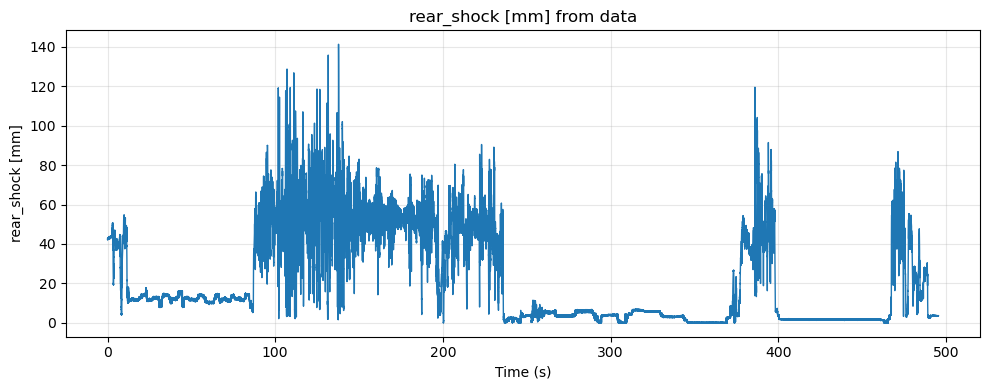

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# === CONFIG ===
df_name = "data"       # name of dataframe (string)
col_name = "rear_shock [mm]"   # column to plot
title = None                        # optional custom title (None = auto)

# --- Retrieve dataframe from globals ---
if df_name not in globals():
    raise RuntimeError(f"DataFrame '{df_name}' not found in globals().")

df = globals()[df_name]
if col_name not in df.columns:
    raise KeyError(f"Column '{col_name}' not found in {df_name}.")

# --- Determine x-axis ---
if isinstance(df.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    x = df.index.total_seconds() if isinstance(df.index, pd.TimedeltaIndex) else df.index
    xlabel = "Time (s)" if isinstance(df.index, pd.TimedeltaIndex) else "Timestamp"
elif "t" in df.columns:
    x = df["t"]
    xlabel = "Time (s)"
else:
    x = df.index
    xlabel = "Sample #"

# --- Plot ---
plt.figure(figsize=(10, 4))
plt.plot(x, df[col_name], linewidth=1.0)
plt.xlabel(xlabel)
plt.ylabel(col_name)
plt.title(title or f"{col_name} from {df_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Trim inactive sections

In [11]:
# === Trim inactive sections based on rolling change across columns ===
import numpy as np, pandas as pd

SOURCE_FRAME = "data"   # or "data_rs" if you truly want that
frame = globals().get(SOURCE_FRAME)
if frame is None:
    raise RuntimeError(f"No frame named {SOURCE_FRAME}.")
print(f"[Trim] Using {SOURCE_FRAME} (rows={len(frame)})")

frame = ensure_time_index(frame)  # <-- fixes your error

if frame is None:
    raise RuntimeError("No data found. Run the Load cell first.")
if not isinstance(frame.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    raise TypeError("Expected a time-based index (Timedelta/Datetime).")

# ---------- CONFIG ----------
MONITOR_COLS = ["rear_shock [mm]"]        # e.g. ["front_travel_mm", "rear_travel_mm"]; None = all numeric cols
WINDOW       = "3000ms"     # rolling window for change detection (e.g. "200ms", "1s")
DEFAULT_EPS  = 0.1         # 'significant' = max-min over WINDOW > threshold (units of each col)
PER_COL_EPS  = {"rear_shock [mm]":20 }          # per-column overrides, e.g. {"front_travel_mm": 1.0}
PADDING      = "2000ms"     # keep a bit of context before/after active regions
MIN_SEGMENT  = "4000ms"     # drop bursts shorter than this after padding
# ---------------------------

num_cols = frame.select_dtypes(include="number").columns.tolist()
cols = [c for c in (MONITOR_COLS or num_cols) if c in frame.columns]
if not cols:
    raise ValueError("No numeric columns to monitor; set MONITOR_COLS to your signal names.")

thr = pd.Series({c: PER_COL_EPS.get(c, DEFAULT_EPS) for c in cols})

# Rolling range (max - min) per column within WINDOW
roll_max   = frame[cols].rolling(WINDOW, min_periods=1).max()
roll_min   = frame[cols].rolling(WINDOW, min_periods=1).min()
roll_range = roll_max - roll_min

# Active where ANY monitored column exceeds its threshold
signif      = (roll_range > thr)
active_mask = signif.any(axis=1)

# Build padded active intervals
pad    = pd.to_timedelta(PADDING)
minseg = pd.to_timedelta(MIN_SEGMENT)

segments = []
if active_mask.any():
    block_id = (active_mask != active_mask.shift(fill_value=False)).cumsum()
    for _, g in active_mask.groupby(block_id):
        if not g.iloc[0]:  # skip False blocks
            continue
        s = g.index[0] - pad
        e = g.index[-1] + pad
        segments.append([s, e])

    # Merge overlapping/adjacent intervals
    segments.sort(key=lambda x: x[0])
    merged = []
    for s, e in segments:
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)

    # Drop very short segments
    merged = [[s, e] for s, e in merged if (e - s) >= minseg]
else:
    merged = []

# Filter the dataframe and also provide per-segment cuts
if merged:
    keep = pd.Series(False, index=frame.index)
    for s, e in merged:
        keep |= (frame.index >= s) & (frame.index <= e)
    data_active = frame.loc[keep].copy()
    segments_active = [frame.loc[(frame.index >= s) & (frame.index <= e)].copy() for s, e in merged]
else:
    data_active = frame.iloc[0:0].copy()
    segments_active = []

print(f"Active segments kept: {len(merged)}")
for i, (s, e) in enumerate(merged, 1):
    print(f"  {i:02d}: {s} → {e}  (duration {(e - s)})")
print("Rows in original:", len(frame), " | Rows kept:", len(data_active))

# Show min / max per numeric column
numeric_cols = data_active.select_dtypes(include=[np.number]).columns

if len(numeric_cols):
    print("\nColumn value ranges (numeric columns only):")
    stats = (
        data_active[numeric_cols]
        .agg(["min", "max"])
        .T  # transpose for readability
        .sort_index()
    )
    # Optional: round for clarity
    with pd.option_context("display.float_format", "{:10.4f}".format):
        print(stats.to_string())
else:
    print("\nNo numeric columns found to show min/max.")

# Optional: make the trimmed set the default for subsequent steps
# data_rs = data_active

#data_active.to_csv("df_after_trim.csv", index=False)



[Trim] Using data (rows=231038)
Active segments kept: 5
  01: 0 days 00:00:01.306000 → 0 days 00:00:16.514000  (duration 0 days 00:00:15.208000)
  02: 0 days 00:01:25.034000 → 0 days 00:02:55.776000  (duration 0 days 00:01:30.742000)
  03: 0 days 00:02:57.416000 → 0 days 00:04:00.954000  (duration 0 days 00:01:03.538000)
  04: 0 days 00:06:11.080000 → 0 days 00:06:43.126000  (duration 0 days 00:00:32.046000)
  05: 0 days 00:07:45.486000 → 0 days 00:08:14.122000  (duration 0 days 00:00:28.636000)
Rows in original: 231038  | Rows kept: 99245

Column value ranges (numeric columns only):
                                min        max
front_shock [mm]            -1.1413   164.2955
front_shock [mm]_norm        0.0000     0.9664
front_shock [mm]_zeroed     -1.1413   164.2955
front_shock_raw [counts]   411.0000  3745.0000
mark                         0.0000     0.0000
rear_shock [mm]              0.0000   141.3622
rear_shock [mm]_norm         0.0000     0.8567
rear_shock [mm]_zeroed       0.00

## Generic plot cell

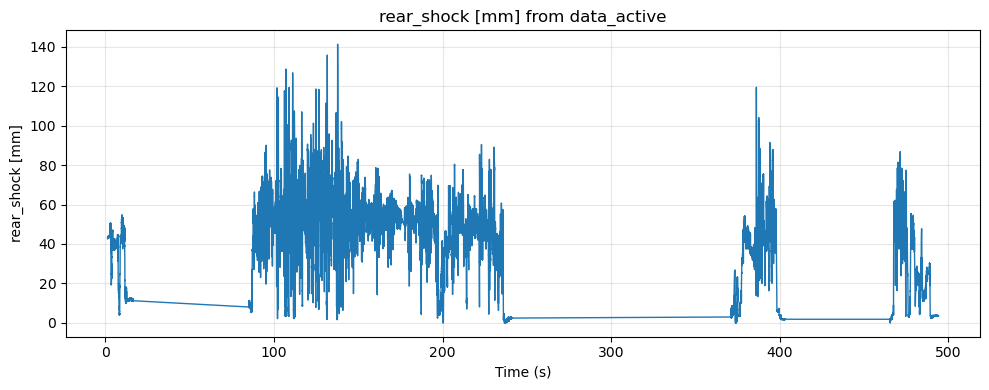

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# === CONFIG ===
df_name = "data_active"       # name of dataframe (string)
col_name = "rear_shock [mm]"   # column to plot
title = None                        # optional custom title (None = auto)

# --- Retrieve dataframe from globals ---
if df_name not in globals():
    raise RuntimeError(f"DataFrame '{df_name}' not found in globals().")

df = globals()[df_name]
if col_name not in df.columns:
    raise KeyError(f"Column '{col_name}' not found in {df_name}.")

# --- Determine x-axis ---
if isinstance(df.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    x = df.index.total_seconds() if isinstance(df.index, pd.TimedeltaIndex) else df.index
    xlabel = "Time (s)" if isinstance(df.index, pd.TimedeltaIndex) else "Timestamp"
elif "t" in df.columns:
    x = df["t"]
    xlabel = "Time (s)"
else:
    x = df.index
    xlabel = "Sample #"

# --- Plot ---
plt.figure(figsize=(10, 4))
plt.plot(x, df[col_name], linewidth=1.0)
plt.xlabel(xlabel)
plt.ylabel(col_name)
plt.title(title or f"{col_name} from {df_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Velocity and Acceleration

In [13]:
# --- Config ---
# Columns to process (zeroed displacement columns). If None, auto-detect numeric, non-time columns.
cols = ["front_shock [mm]", "rear_shock [mm]"]

# Sampling: either set sample_rate_hz OR ensure your index is DatetimeIndex OR there is a 'time_s' column.
sample_rate_hz   = 500       # e.g., 1000.0
time_column_name = "time_s"  # set to None if deriving from DatetimeIndex

# Savitzky–Golay parameters
window_points = 11      # must be odd; typical 7–21
poly_order    = 3       # < window_points; typical 2–4

# Suffixes for outputs
VEL_SUFFIX = "_vel"
ACC_SUFFIX = "_acc"

# --- Implementation ---
import numpy as np
import pandas as pd

# <<< NEW: define _first_frame so this cell is self-contained >>>
def _first_frame():
    # Prefer trimmed; else resampled; else raw — but only if it exists and isn't empty
    for name in ("data_active", "data_rs", "data"):
        obj = globals().get(name, None)
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            return obj, name
    raise RuntimeError("No non-empty DataFrame found (looked for data_active, data_rs, data).")

# Try SciPy; if missing, we’ll use a NumPy fallback
try:
    from scipy.signal import savgol_filter
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

def _infer_dt(df, sample_rate_hz=None, time_col="time_s"):
    """Infer dt (s) from explicit sample rate, a time column, or a DatetimeIndex."""
    if sample_rate_hz is not None:
        return 1.0 / float(sample_rate_hz)
    # try explicit time column
    if time_col and time_col in df.columns:
        t = pd.to_numeric(df[time_col], errors="coerce").to_numpy()
        dt = np.median(np.diff(t))
        if np.isfinite(dt) and dt > 0:
            return float(dt)
    # try a common alternative name
    if "t" in df.columns:
        t = pd.to_numeric(df["t"], errors="coerce").to_numpy()
        d = np.diff(t)
        d = d[(d > 0) & np.isfinite(d)]
        if d.size:
            return float(np.median(d))
    # try DatetimeIndex
    if isinstance(df.index, pd.DatetimeIndex):
        dt = pd.Series(df.index).diff().dt.total_seconds().median()
        if np.isfinite(dt) and dt > 0:
            return float(dt)
    raise ValueError("Cannot infer dt. Provide sample_rate_hz or a valid time column or DatetimeIndex.")

def _pick_cols(df, cols):
    """Pick numeric columns to process, excluding obvious time-like columns."""
    if cols is not None:
        return list(cols)
    drop_like = {"time", "timestamp", "date"}
    cands = []
    for c in df.select_dtypes(include=[np.number]).columns:
        lc = c.lower()
        if any(k in lc for k in drop_like):
            continue
        cands.append(c)
    if not cands:
        raise ValueError("No numeric columns found to process. Set 'cols' explicitly.")
    return cands

def _validate_params(window_points, poly_order):
    if window_points % 2 == 0:
        raise ValueError("window_points must be odd.")
    if poly_order >= window_points:
        raise ValueError("poly_order must be < window_points.")
    if poly_order < 1:
        raise ValueError("poly_order should be >= 1.")

def _savgol_numpy(y, window_points, poly_order, deriv, dt):
    """
    Minimal SG fallback using NumPy:
    - Build local polynomial basis (centered window),
    - Convolve with derivative coefficients,
    - Reflect-pad edges.
    """
    n = len(y)
    if n < window_points:
        # shrink to nearest odd <= n (keeps behaviour sane on very short slices)
        window_points = max(3, (n // 2) * 2 + 1)
        if poly_order >= window_points:
            poly_order = max(1, window_points - 1)

    half = window_points // 2
    x = np.arange(-half, half + 1, dtype=float)
    A = np.vander(x, N=poly_order + 1, increasing=True)  # columns: x^0..x^p
    pinv = np.linalg.pinv(A)
    coeff = pinv[deriv, :] * np.math.factorial(deriv)     # derivative at x=0
    scale = (dt ** (-deriv))

    # Reflect-pad
    left  = y[1:half+1][::-1] if n > 1 else np.array([y[0]] * half)
    right = y[-half-1:-1][::-1] if n > 1 else np.array([y[-1]] * half)
    ypad = np.r_[left, y, right]
    filt = np.convolve(ypad, coeff[::-1], mode="valid") * scale
    return filt

def estimate_va_from_zeroed(df,
                            cols=None,
                            sample_rate_hz=None,
                            time_col="time_s",
                            window_points=11,
                            poly_order=3,
                            vel_suffix=VEL_SUFFIX,
                            acc_suffix=ACC_SUFFIX):
    _validate_params(window_points, poly_order)
    dt = _infer_dt(df, sample_rate_hz=sample_rate_hz, time_col=time_col)
    target_cols = _pick_cols(df, cols)

    out = df.copy()
    # interpolate numeric gaps gently
    data = out[target_cols].apply(pd.to_numeric, errors="coerce").interpolate(limit_direction="both")

    for c in target_cols:
        y = data[c].to_numpy()
        if _HAVE_SCIPY:
            v = savgol_filter(y, window_points, poly_order, deriv=1, delta=dt, mode="interp")
            a = savgol_filter(y, window_points, poly_order, deriv=2, delta=dt, mode="interp")
        else:
            v = _savgol_numpy(y, window_points, poly_order, deriv=1, dt=dt)
            a = _savgol_numpy(y, window_points, poly_order, deriv=2, dt=dt)
        out[c + vel_suffix] = v
        out[c + acc_suffix] = a

    return out, {"dt": dt, "window_points": window_points, "poly_order": poly_order, "cols": target_cols}

# ---- Run on the currently active frame (data_active, else data_rs, else data) ----
df_src, src_name = _first_frame()

df_va, meta_va = estimate_va_from_zeroed(
    df_src,
    cols=cols,
    sample_rate_hz=sample_rate_hz,
    time_col=time_column_name,
    window_points=window_points,
    poly_order=poly_order,
)

# Expose result under a convenient global name, e.g. "data_va" if source was "data"
out_name = f"{src_name}_va"
globals()[out_name] = df_va
df_va  # also leave it as the last expression for notebook display

print(
    f"[VA] Source='{src_name}' → Output='{out_name}'. "
    f"Cols={meta_va['cols']}, dt={meta_va['dt']:.6f}s, "
    f"window={meta_va['window_points']}, order={meta_va['poly_order']}"
)


[VA] Source='data_active' → Output='data_active_va'. Cols=['front_shock [mm]', 'rear_shock [mm]'], dt=0.002000s, window=11, order=3


## Resample

In [14]:

if RESAMPLE_HZ:
    data = ensure_time_index(data)                      # make t (s) the TimedeltaIndex
    data_rs = resample_df(data, rate_hz=RESAMPLE_HZ, how="mean")
    print(f"Resampled to {RESAMPLE_HZ} Hz: {len(data_rs):,} rows")
else:
    data_rs = data.copy()


Resampled to 500 Hz: 247,791 rows


## Config for event analysis: explicitly set columns and data frame

In [15]:
# === Analysis Config: Explicit input selection + time hygiene ===
import numpy as np
import pandas as pd

# --- USER CONFIG ---
INPUT_FRAME   = "data_active_va"   # e.g. "data", "data_rs", "data_active", "data_active_va"
INPUT_COLUMNS = [
    "front_shock [mm]",       # displacement    
    "front_shock [mm]_vel",   # velocity
    "front_shock [mm]_acc",   # acceleration
    "rear_shock [mm]",        # displacement
    "rear_shock [mm]_vel",    # velocity
    "rear_shock [mm]_acc",    # acceleration

]
OUTPUT_NAME   = "event_analysis_df"
META_NAME     = "event_analysis_meta"

# Time repair / gap marking parameters (used only if a clean 't' isn't already present)
DT_HINT = None       # e.g., 0.01 for 100 Hz; None = infer
GAP_FACTOR = 10.0    # gap if Δt > GAP_FACTOR * median(Δt)
GAP_MIN_S  = None    # or absolute gap threshold (e.g., 0.2)
MIN_STEP_FACTOR = 0.5  # when repairing backsteps, insert at least MIN_STEP_FACTOR*dt_hint
# -------------------

# --- Helpers (lightweight, local) ---
def _derive_time_seconds(df: pd.DataFrame) -> np.ndarray:
    # Prefer numeric time column if present
    for c in ("t", "time_s"):
        if c in df.columns and np.issubdtype(df[c].dtype, np.number):
            return df[c].to_numpy(dtype=float)
    # Otherwise try common timestamp names
    for c in ("timestamp", "time"):
        if c in df.columns:
            s = df[c]
            if np.issubdtype(s.dtype, np.datetime64) or s.dtype == object:
                dt = pd.to_datetime(s, utc=False, errors="coerce")
                if dt.isna().all():
                    continue
                t0 = dt.iloc[0]
                return (dt - t0).dt.total_seconds().to_numpy()
    # Fallback: datetime-like index
    idx = df.index
    if isinstance(idx, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        return (idx - idx[0]).total_seconds()
    # Last resort: unit steps (we'll still compute dt)
    n = len(df)
    if n > 1:
        return np.arange(n, dtype=float)
    raise RuntimeError("Could not infer time base: provide a 't' or 'time_s' column, or a datetime index.")

def _repair_monotonic(t: np.ndarray, dt_hint=None, min_step_factor=0.5):
    t = np.asarray(t, dtype=float).copy()
    diffs = np.diff(t)
    if dt_hint is None:
        finite = diffs[np.isfinite(diffs)]
        if finite.size:
            finite_pos = finite[(finite > 0) & (finite < np.nanpercentile(finite, 95))]
            median_dt = float(np.nanmedian(finite_pos)) if finite_pos.size else 0.0
        else:
            median_dt = 0.0
    else:
        median_dt = float(dt_hint)
    min_step = median_dt * float(min_step_factor) if median_dt > 0 else 0.0

    bumps = 0
    total_added = 0.0
    for i in range(1, len(t)):
        if t[i] + 1e-12 < t[i-1]:
            bump = (t[i-1] - t[i]) + (min_step if min_step > 0 else 0.0)
            t[i:] += bump
            total_added += bump
            bumps += 1
    return t, bumps, total_added, median_dt

def _mark_gaps(t: np.ndarray, gap_factor=10.0, gap_min_s=None):
    dt = np.diff(t, prepend=t[0])
    finite = dt[np.isfinite(dt)]
    med = float(np.nanmedian(finite[finite > 0])) if np.any(finite > 0) else 0.0
    thr = max(gap_min_s or 0.0, (gap_factor * med) if med > 0 else 0.0)
    gap_mask = (dt > thr) if thr > 0 else np.zeros_like(dt, dtype=bool)
    gap_mask[0] = False
    segment_id = np.cumsum(gap_mask).astype(int)
    return gap_mask, segment_id, thr

def _insert_plot_breaks(df: pd.DataFrame, gap_mask: np.ndarray, value_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    if value_cols:
        out.loc[gap_mask, value_cols] = np.nan
    return out

# --- Implementation ---
obj = globals().get(INPUT_FRAME, None)
if not isinstance(obj, pd.DataFrame) or obj.empty:
    raise RuntimeError(f"Input frame '{INPUT_FRAME}' not found or empty. Check that you loaded your data.")

missing = [c for c in INPUT_COLUMNS if c not in obj.columns]
if missing:
    raise RuntimeError(f"Missing columns in '{INPUT_FRAME}': {missing}")

# 1) Build/verify time column 't'
had_t = "t" in obj.columns and np.issubdtype(obj["t"].dtype, np.number)
t0 = obj["t"].to_numpy(dtype=float) if had_t else _derive_time_seconds(obj)
t_fixed, n_back, added, inferred_dt = _repair_monotonic(t0, dt_hint=DT_HINT, min_step_factor=MIN_STEP_FACTOR)

# 2) Mark large gaps and build segment_id (only matters for plotting/inspection)
gap_mask, segment_id, gap_thr = _mark_gaps(t_fixed, gap_factor=GAP_FACTOR, gap_min_s=GAP_MIN_S)

# 3) Create a working copy of the source with clean time metadata
src = obj.copy()
if "t_raw" not in src.columns:
    src["t_raw"] = t0
src["t"] = t_fixed
src["segment_id"] = segment_id
src["time_backstep_flag"] = False
if n_back > 0:
    back_flag = np.zeros(len(src), dtype=bool)
    back_flag[1:] = np.diff(t0) < 0
    src["time_backstep_flag"] = back_flag

# 4) Build a plot-safe view that breaks lines at gaps
value_cols = [c for c in src.columns if c not in ("t","t_raw","segment_id","time_backstep_flag")]
plot_view = _insert_plot_breaks(src, gap_mask, value_cols=value_cols)
globals()[f"plot_view_{INPUT_FRAME}"] = plot_view  # convenience for quick plotting

# 5) Assemble the minimal analysis frame (selected columns + clean 't')
event_analysis_df = src[INPUT_COLUMNS + ["t"]].copy()
event_analysis_df = ensure_time_index(event_analysis_df)


# 6) Compute robust dt (median spacing on the fixed time)
dt = float(np.nanmedian(np.diff(event_analysis_df["t"].to_numpy()))) if len(event_analysis_df) > 1 else None

# 7) Register globals
globals()[OUTPUT_NAME] = event_analysis_df
globals()[META_NAME] = {
    "source": INPUT_FRAME,
    "columns": INPUT_COLUMNS,
    "dt": dt,
    "nrows": len(event_analysis_df),
    "n_backsteps_repaired": int(n_back),
    "total_seconds_added": float(added),
    "gap_threshold_s": float(gap_thr),
}

# 8) Status
print(f"[Config] Using {INPUT_FRAME} with {len(event_analysis_df)} rows → {OUTPUT_NAME}")
print("Columns:", ", ".join(event_analysis_df.columns))
if dt:
    print(f"Derived dt ≈ {dt:.6f} s (inferred base dt ≈ {inferred_dt:.6f} s)")
if n_back > 0:
    print(f"[TimeFix] Repaired {n_back} backward step(s); total +{added:.6f} s added.")
print(f"[TimeFix] Gap threshold ≈ {gap_thr:.6g} s; segments = {int(segment_id.max()+1)}")
print(f"Plot-safe view available as: plot_view_{INPUT_FRAME}")

event_analysis_df.to_csv("event_analysis_df_data.csv", index=False)


[Config] Using data_active_va with 99245 rows → event_analysis_df
Columns: front_shock [mm], front_shock [mm]_vel, front_shock [mm]_acc, rear_shock [mm], rear_shock [mm]_vel, rear_shock [mm]_acc, t
Derived dt ≈ 0.002000 s (inferred base dt ≈ 0.002000 s)
[TimeFix] Gap threshold ≈ 0.02 s; segments = 236
Plot-safe view available as: plot_view_data_active_va


## Load and validate event schema

In [22]:
# === Load + summarize event schema (YAML) ===
import os, io, hashlib
from typing import Any, Dict, List, Tuple
import pandas as pd

# If PyYAML isn't installed in your env, run: pip install pyyaml
import yaml

# A SafeLoader that DOESN'T auto-coerce "on/off/yes/no" to booleans (YAML 1.1 behavior)
class NoBoolSafeLoader(yaml.SafeLoader):
    pass

# Remove the implicit resolver for booleans
for ch, resolvers in list(NoBoolSafeLoader.yaml_implicit_resolvers.items()):
    NoBoolSafeLoader.yaml_implicit_resolvers[ch] = [
        (tag, regexp) for (tag, regexp) in resolvers
        if tag != 'tag:yaml.org,2002:bool'
    ]

def load_event_schema(path: str):
    data_bytes = open(path, "rb").read()
    schema = yaml.load(io.BytesIO(data_bytes), Loader=NoBoolSafeLoader)
    return schema, hashlib.sha256(data_bytes).hexdigest()



# ---- Config: update path if needed ----
SCHEMA_PATH = "event_schema.yaml"

# ---- Helpers ----
def _read_file_bytes(path: str) -> bytes:
    with open(path, "rb") as f:
        return f.read()

def _sha256(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def load_event_schema(path: str) -> Tuple[Dict[str, Any], str]:
    data_bytes = _read_file_bytes(path)
    h = _sha256(data_bytes)
    schema = yaml.safe_load(io.BytesIO(data_bytes))
    if not isinstance(schema, dict):
        raise ValueError("Top-level YAML must be a mapping (dict).")
    return schema, h

def basic_validate(schema: Dict[str, Any]) -> List[str]:
    """Lightweight sanity checks; returns a list of issues (empty if OK)."""
    issues = []
    # events list present & non-empty
    if "events" not in schema or not isinstance(schema["events"], list) or not schema["events"]:
        issues.append("Missing or empty 'events' list.")
        return issues
    # per-event checks
    for i, ev in enumerate(schema["events"]):
        prefix = f"events[{i}]"
        if not isinstance(ev, dict):
            issues.append(f"{prefix}: must be a mapping.")
            continue
        for k in ("id", "sensor", "trigger"):
            if k not in ev:
                issues.append(f"{prefix}: missing required key '{k}'.")
        trig = ev.get("trigger", {})
        if isinstance(trig, dict):
            t = trig.get("type")
            if t not in ("local_extrema", "threshold_crossing", "zero_crossing", "custom"):
                issues.append(f"{prefix}.trigger.type '{t}' not in allowed set.")
        else:
            issues.append(f"{prefix}.trigger must be a mapping.")
        win = ev.get("window", None)
        if win is not None and not isinstance(win, dict):
            issues.append(f"{prefix}.window must be a mapping if present.")
        deb = ev.get("debounce_s", None)
        if deb is not None and not isinstance(deb, (int, float)):
            issues.append(f"{prefix}.debounce_s must be a number (seconds).")
    return issues

def summarize_events(schema: Dict[str, Any]) -> pd.DataFrame:
    """Create a concise per-event summary table."""
    rows = []
    defaults = schema.get("defaults", {})
    def_pre = (defaults.get("window", {}) or {}).get("pre_s", None)
    def_post = (defaults.get("window", {}) or {}).get("post_s", None)
    def_align = (defaults.get("window", {}) or {}).get("align", None)
    def_debounce = defaults.get("debounce_s", None)

    for ev in schema["events"]:
        trig = ev.get("trigger", {})
        ttype = trig.get("type")
        on = trig.get("on")
        kind = trig.get("kind") or trig.get("dir")
        prom = trig.get("prominence")
        thresh = trig.get("value")
        hyster = trig.get("hysteresis")
        window = ev.get("window", {})
        pre = window.get("pre_s", def_pre)
        post = window.get("post_s", def_post)
        align = window.get("align", def_align)
        debounce = ev.get("debounce_s", def_debounce)
        metrics = ev.get("metrics", [])

        rows.append({
            "id": ev.get("id"),
            "label": ev.get("label"),
            "sensor": ev.get("sensor"),
            "trigger": ttype,
            "on": on,
            "kind/dir": kind,
            "prominence": prom,
            "threshold": thresh,
            "hysteresis": hyster,
            "pre_s": pre,
            "post_s": post,
            "align": align,
            "debounce_s": debounce,
            "n_metrics": len(metrics),
        })
    cols = ["id","label","sensor","trigger","on","kind/dir","prominence","threshold","hysteresis",
            "pre_s","post_s","align","debounce_s","n_metrics"]
    return pd.DataFrame(rows, columns=cols)

# ---- Execute: load, validate, summarize ----
schema, schema_hash = load_event_schema(SCHEMA_PATH)
issues = basic_validate(schema)
summary_df = summarize_events(schema)

print(f"Loaded event schema from: {SCHEMA_PATH}")
print(f"Schema version: {schema.get('version','(none)')}")
print(f"Events defined: {len(schema.get('events', []))}")
print(f"SHA256: {schema_hash}")
print("\nSchema passed basic validation." if not issues else "\nVALIDATION ISSUES:\n - " + "\n - ".join(issues))

# Optional: display a compact table (works nicely in notebooks)
try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("Event Schema Summary", summary_df)
except Exception:
    # Fallback to plain display if the helper isn't available
    display(summary_df)

# Expose globals for later cells
EVENT_SCHEMA = schema
EVENT_SCHEMA_HASH = schema_hash
EVENT_SCHEMA_SUMMARY = summary_df


Loaded event schema from: event_schema.yaml
Schema version: 1.1
Events defined: 1
SHA256: d621d9b200ff7a456544bec65529c2cabc34d1da11b820b85471e7bb4ca7aeb2

VALIDATION ISSUES:
 - events[0]: missing required key 'sensor'.


,id,label,sensor,trigger,on,kind/dir,prominence,threshold,hysteresis,pre_s,post_s,align,debounce_s,n_metrics
0,deep_compression,deep compression (>0.9),None,local_extrema,disp,max,1.0,None,None,0.5,0.8,trigger,0.3,3


## Build events table

In [20]:
# === Event detection engine → EVENTS_DF ===
import math
import numpy as np
import pandas as pd

# Optional SciPy peak detection (more robust prominence/distance handling)
try:
    from scipy.signal import find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ---------------- Basics & helpers ----------------
# --- Ensure inputs are available to the detector (drop-in fix) ---
def _require_inputs():
    """
    Return (event_analysis_df, event_analysis_meta, EVENT_SCHEMA).
    Falls back sensibly if meta/schema aren't present yet.
    """
    # DataFrame
    df = globals().get("event_analysis_df", None)
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise RuntimeError("Missing 'event_analysis_df'. Run the analysis config cell that creates it.")

    # Meta
    meta = globals().get("event_analysis_meta", None)
    if not isinstance(meta, dict):
        # build a lightweight meta on the fly
        dt = np.nan
        if "t" in df.columns and len(df) > 1:
            d = np.diff(pd.to_numeric(df["t"], errors="coerce"))
            d = d[(d > 0) & np.isfinite(d)]
            if d.size:
                dt = float(np.median(d))
        meta = {"source": "(unknown)", "columns": list(df.columns), "dt": dt, "nrows": len(df)}
        globals()["event_analysis_meta"] = meta  # expose for later

    # Schema
    schema = globals().get("EVENT_SCHEMA", None)
    if not isinstance(schema, dict) or not schema:
        raise RuntimeError("Missing 'EVENT_SCHEMA'. Load your YAML schema into EVENT_SCHEMA before running detection.")

    return df, meta, schema


def _validate_event_series(ev: dict, df: pd.DataFrame):
    """Ensure trigger.on is mapped in inputs and columns exist."""
    ev_id = ev.get("id", "(unknown)")
    trig = ev.get("trigger", {}) or {}
    inputs = ev.get("inputs", {}) or {}
    on = trig.get("on")

    if on:
        if on not in inputs:
            raise KeyError(
                f"Event '{ev_id}': trigger.on='{on}' but inputs only has {list(inputs.keys())}."
            )
        col = inputs[on]
        if col not in df.columns:
            raise KeyError(
                f"Event '{ev_id}': inputs.{on} refers to column '{col}', which is not in event_analysis_df."
            )

    def _collect_refs(blocks):
        refs = set()
        for blk in (blocks or []):
            for key in ("any_of","all_of"):
                for test in (blk.get(key) or []):
                    onx = test.get("on")
                    if onx:
                        refs.add(onx)
        return refs

    cond_refs = _collect_refs(ev.get("preconditions")) | _collect_refs(ev.get("postconditions"))
    metric_refs = set(m.get("on") for m in (ev.get("metrics") or []) if m.get("on"))
    needed = set(x for x in (cond_refs | metric_refs) if x)

    for name in needed:
        if name not in inputs:
            raise KeyError(
                f"Event '{ev_id}': a condition/metric references '{name}', "
                f"but inputs only has {list(inputs.keys())}."
            )
        col = inputs[name]
        if col not in df.columns:
            raise KeyError(
                f"Event '{ev_id}': inputs.{name} refers to column '{col}', which is not in event_analysis_df."
            )

# <<< NEW: robust dt computation >>>
def _robust_dt(df: pd.DataFrame, meta: dict) -> float:
    dt = float(meta.get("dt", np.nan))
    if not np.isfinite(dt) or dt <= 0:
        if "t" in df.columns and len(df["t"]) > 1:
            diffs = np.diff(df["t"].to_numpy(dtype=float))
            diffs = diffs[(diffs > 0) & np.isfinite(diffs)]
            if diffs.size:
                dt = float(np.median(diffs))
    # If still invalid, return NaN; callers will guard
    return dt

# <<< CHANGED: seconds→samples now returns None when dt invalid >>>
def _sec_to_samples_opt(s: float | None, dt: float) -> int | None:
    if s is None:
        return None
    if not np.isfinite(dt) or dt <= 0:
        return None
    # allow 0 for zero-length (e.g., pre_s=0); min positive will be handled by callers where needed
    return int(round(float(s) / float(dt)))

def _clip_bounds(n: int, i0: int, i1: int):
    return max(0, i0), min(n, i1)

def _series_get(df: pd.DataFrame, name: str):
    if not name:
        raise KeyError("Series name is None — check that trigger.on maps to inputs.<on> in your YAML.")
    if name not in df.columns:
        raise KeyError(f"Series '{name}' not found in event_analysis_df columns.")
    return df[name].to_numpy()

def _nan_frac(arr):
    return float(np.mean(np.isnan(arr))) if arr.size else 1.0

# ---------- New: inputs resolver + event expander ----------

def _inputs_map_for(ev: dict, schema: dict, sensor_name: str | None) -> dict:
    """
    Return an explicit {disp: col, vel: col, acc: col} mapping for this event.
    - If the event is in 'suffix' mode, build names as f"{sensor}{suffix}" using schema.naming.suffixes.
    - If the event is legacy (explicit columns), pass through ev['inputs'].
    """
    inputs = (ev.get("inputs") or {})
    mode = inputs.get("mode")

    # Suffix-mode if:
    #  - inputs.mode == "suffixes", OR
    #  - 'sensors' is present and explicit disp/vel/acc were not provided
    suffix_mode = (mode == "suffixes") or ("sensors" in ev and not {"disp", "vel", "acc"} <= set(inputs.keys()))

    if suffix_mode:
        if not sensor_name:
            raise ValueError(f"Event '{ev.get('id','?')}' needs a sensor for suffix resolution.")
        suffixes = ((schema.get("naming") or {}).get("suffixes") or {})
        missing = [k for k in ("disp","vel","acc") if k not in suffixes]
        if missing:
            raise KeyError(f"Schema.naming.suffixes missing keys {missing} required for event '{ev.get('id','?')}'.")
        return {
            "disp": f"{sensor_name}{suffixes['disp']}",
            "vel":  f"{sensor_name}{suffixes['vel']}",
            "acc":  f"{sensor_name}{suffixes['acc']}",
        }

    # Legacy explicit mapping
    out = {}
    for k in ("disp","vel","acc"):
        if k in inputs:
            out[k] = inputs[k]
    return out


def _expand_event_by_sensors(ev: dict, schema: dict) -> list[dict]:
    """
    Turn one (possibly multi-sensor) event into a list of per-sensor events,
    each with an explicit 'sensor' and resolved 'inputs' mapping.
    Legacy single-sensor events pass through unchanged.
    """
    sensors = ev.get("sensors")
    if not sensors:
        # Legacy path: ensure 'sensor' present and inputs explicit
        ev2 = dict(ev)
        if "sensor" not in ev2:
            raise KeyError(f"Event '{ev.get('id','?')}' missing 'sensor' (legacy mode).")
        ev2["inputs"] = _inputs_map_for(ev2, schema, ev2["sensor"])
        return [ev2]

    out = []
    for s in sensors:
        ev2 = dict(ev)
        ev2["sensor"] = s  # per-sensor instance
        ev2["inputs"] = _inputs_map_for(ev, schema, s)  # explicit mapping for this sensor
        out.append(ev2)
    return out


# ---------------- Triggers ----------------
def _trigger_local_extrema(df, dt, ev):
    trig = ev["trigger"]
    on = trig.get("on")            # 'disp' | 'vel' | 'acc'
    kind = trig.get("kind")        # 'min' | 'max'
    prom = trig.get("prominence")  # units of the chosen series
    dist_s = trig.get("distance_s")
    edge_ignore_s = trig.get("edge_ignore_s")

    series_name = ev["inputs"].get(on)
    y = _series_get(df, series_name).copy()

    n = len(y)
    # <<< CHANGED: guard edge ignore when dt invalid >>>
    edge = _sec_to_samples_opt(edge_ignore_s, dt)
    if edge is None: edge = 0
    valid_lo, valid_hi = edge, n - edge

    if kind == "min":
        y_proc = -y
        prom_arg = prom if prom is None else float(prom)
    else:
        y_proc = y
        prom_arg = prom if prom is None else float(prom)

    # <<< CHANGED: guard distance when dt invalid >>>
    distance = _sec_to_samples_opt(dist_s, dt)

    if _HAVE_SCIPY:
        kwargs = {}
        if prom_arg is not None:
            kwargs["prominence"] = prom_arg
        if (distance is not None) and (distance > 1):
            kwargs["distance"] = int(distance)
        idx, props = find_peaks(y_proc, **kwargs)
        prominences = props.get("prominences", np.full_like(idx, np.nan, dtype=float)) if props else np.full(0, np.nan)
    else:
        # Simple fallback
        idx = np.arange(1, n-1)
        if kind == "min":
            cand = idx[(y[idx] < y[idx-1]) & (y[idx] <= y[idx+1])]
            win = max(5, int(distance) if distance else 5)
            prominences = []
            kept = []
            for i in cand:
                L = max(0, i-win); R = min(n, i+win+1)
                ref = np.nanmax(y[L:R])
                p = (ref - y[i])
                if prom is None or (p >= prom):
                    kept.append(i); prominences.append(p)
            idx = np.array(kept, dtype=int)
            prominences = np.array(prominences, dtype=float)
        else:
            cand = idx[(y[idx] > y[idx-1]) & (y[idx] >= y[idx+1])]
            win = max(5, int(distance) if distance else 5)
            prominences = []
            kept = []
            for i in cand:
                L = max(0, i-win); R = min(n, i+win+1)
                ref = np.nanmin(y[L:R])
                p = (y[i] - ref)
                if prom is None or (p >= prom):
                    kept.append(i); prominences.append(p)
            idx = np.array(kept, dtype=int)
            prominences = np.array(prominences, dtype=float)

    # Edge ignore
    if edge > 0 and len(idx):
        m = (idx >= valid_lo) & (idx < valid_hi)
        idx = idx[m]
        prominences = prominences[m] if len(prominences) else prominences

    # Package
    t = df["t"].to_numpy()
    out = []
    for i, p in zip(idx, prominences if len(prominences) else [np.nan]*len(idx)):
        out.append({
            "t0_index": int(i),
            "t0_time": float(t[i]),
            "trigger_strength": float(p) if np.isfinite(p) else None,
            "trigger_value": float(y[i]) if np.isfinite(y[i]) else None,
        })
    return out

def _trigger_threshold_crossing(df, dt, ev):
    trig = ev["trigger"]
    on = trig.get("on")
    direction = trig.get("dir", "either")
    value = float(trig.get("value"))
    hyster = float(trig.get("hysteresis", 0.0))

    series_name = ev["inputs"].get(on)
    y = _series_get(df, series_name).copy()
    t = df["t"].to_numpy()

    crossings = []
    armed_rising = True
    armed_falling = True

    for i in range(1, len(y)):
        y0, y1 = y[i-1], y[i]
        if direction in ("rising", "either"):
            if armed_rising and (y0 < value) and (y1 >= value):
                crossings.append(i)
                armed_rising = False
            if (y1 <= value - hyster):
                armed_rising = True
        if direction in ("falling", "either"):
            if armed_falling and (y0 > value) and (y1 <= value):
                crossings.append(i)
                armed_falling = False
            if (y1 >= value + hyster):
                armed_falling = True

    crossings = np.unique(np.asarray(crossings, dtype=int))
    return [{"t0_index": int(i), "t0_time": float(t[i]), "trigger_strength": None, "trigger_value": float(y[i])} for i in crossings]

def _trigger_zero_crossing(df, dt, ev):
    trig = ev["trigger"].copy()
    trig.setdefault("value", 0.0)
    ev2 = dict(ev); ev2["trigger"] = trig
    return _trigger_threshold_crossing(df, dt, ev2)

# ---------------- Conditions ----------------
def _eval_simple_tests(df, t0_idx, t, tests, inputs_map):
    def _sel(name): return df[inputs_map[name]].to_numpy()

    for test in tests:
        typ = test.get("type")
        on = test.get("on")
        if on not in inputs_map:
            return False
        y = _sel(on)

        w = test.get("_slice")
        seg = y[w[0]:w[1]] if w is not None else y
        if seg.size == 0:
            return False

        if typ == "range":
            lo = test.get("min", -np.inf)
            hi = test.get("max", np.inf)
            if not (np.nanmin(seg) >= lo and np.nanmax(seg) <= hi):
                return False

        elif typ == "delta":
            op = test.get("op", ">=")
            val = float(test.get("value", 0.0))
            ref = y[t0_idx]
            dseg = seg - ref
            cond = {
                ">=": np.nanmax(dseg) >= val,
                "<=": np.nanmin(dseg) <= val,
                ">":  np.nanmax(dseg) >  val,
                "<":  np.nanmin(dseg) <  val,
            }.get(op, False)
            if not cond:
                return False

        elif typ == "peak":
            kind = test.get("kind", "max")
            op = test.get("op", ">=")
            val = float(test.get("value", 0.0))
            peak_val = np.nanmax(seg) if kind == "max" else np.nanmin(seg)
            cond = {
                ">=": peak_val >= val,
                "<=": peak_val <= val,
                ">":  peak_val >  val,
                "<":  peak_val <  val,
            }.get(op, False)
            if not cond:
                return False
        else:
            return False
    return True

def _apply_conditions(df, dt, ev, t0_idx):
    inputs_map = ev.get("inputs", {})
    t = df["t"].to_numpy()

    # <<< CHANGED: make_slice tolerates invalid dt by yielding a 1-sample window >>>
    def make_slice(within):
        start_s, end_s = within
        n = len(df)
        def _s2n(sec):
            k = _sec_to_samples_opt(sec, dt)
            return int(k) if (k is not None) else 0
        i0 = t0_idx + _s2n(start_s)
        i1 = t0_idx + _s2n(end_s)
        if i1 < i0:
            i0, i1 = i1, i0
        i0, i1 = _clip_bounds(n, i0, i1)
        if i1 <= i0:
            i1 = min(n, i0 + 1)
        return (i0, i1)

    for block in (ev.get("preconditions") or []):
        w = make_slice(block.get("within_s", [-np.inf, 0.0]))
        any_of = block.get("any_of"); all_of = block.get("all_of")
        if any_of:
            ok_any = False
            for test in any_of:
                test = dict(test); test["_slice"] = w
                if _eval_simple_tests(df, t0_idx, t, [test], inputs_map):
                    ok_any = True; break
            if not ok_any:
                return False
        if all_of:
            tests = []
            for test in all_of:
                test = dict(test); test["_slice"] = w
                tests.append(test)
            if not _eval_simple_tests(df, t0_idx, t, tests, inputs_map):
                return False

    for block in (ev.get("postconditions") or []):
        w = make_slice(block.get("within_s", [0.0, np.inf]))
        any_of = block.get("any_of"); all_of = block.get("all_of")
        if any_of:
            ok_any = False
            for test in any_of:
                test = dict(test); test["_slice"] = w
            # If none pass, fail
            for test in (any_of or []):
                t2 = dict(test); t2["_slice"] = w
                if _eval_simple_tests(df, t0_idx, t, [t2], inputs_map):
                    ok_any = True; break
            if not ok_any:
                return False
        if all_of:
            tests = []
            for test in (all_of or []):
                t2 = dict(test); t2["_slice"] = w
                tests.append(t2)
            if tests and (not _eval_simple_tests(df, t0_idx, t, tests, inputs_map)):
                return False

    return True

# ---------------- Debounce & metrics ----------------
def _debounce_and_select(cands, dt, min_gap_s, prefer_key="trigger_strength", prefer_abs=False):
    if not cands:
        return []
    # <<< CHANGED: skip debouncing if dt invalid >>>
    if not min_gap_s or min_gap_s <= 0 or (not np.isfinite(dt) or dt <= 0):
        return cands

    min_gap = _sec_to_samples_opt(min_gap_s, dt)
    if min_gap is None or min_gap <= 0:
        return cands

    cands = sorted(cands, key=lambda d: d["t0_index"])
    out = []
    cluster = [cands[0]]

    def score(c):
        v = c.get(prefer_key)
        if v is None: return -np.inf
        return abs(v) if prefer_abs else v

    for c in cands[1:]:
        if c["t0_index"] - cluster[-1]["t0_index"] < min_gap:
            cluster.append(c)
        else:
            best = max(cluster, key=score); out.append(best); cluster = [c]
    out.append(max(cluster, key=score))
    return out

def _compute_metrics(df, dt, ev, t0_idx, start_idx, end_idx):
    t = df["t"].to_numpy()
    seg = df.iloc[start_idx:end_idx]
    metrics = ev.get("metrics", []) or []
    out = {}

    def _arr(name):
        return seg[ev["inputs"][name]].to_numpy() if name in ev["inputs"] else None

    for m in metrics:
        mtype = m.get("type"); on = m.get("on")
        if on and on not in ev["inputs"]:
            continue
        y = _arr(on) if on else None

        if mtype == "integral" and y is not None:
            # If dt invalid, fall back to sample-spacing = 1 (relative units)
            dx = dt if (np.isfinite(dt) and dt > 0) else 1.0
            val = np.trapezoid(np.abs(y), dx=dx) if m.get("abs", False) else np.trapezoid(y, dx=dx)
            out[f"m_integral_{on}{'_abs' if m.get('abs', False) else ''}"] = float(val)

        elif mtype == "peak" and y is not None:
            kind = m.get("kind", "max")
            if kind == "max":
                idx_rel = int(np.nanargmax(y)) if len(y) else 0
                val = float(np.nanmax(y)) if len(y) else np.nan
            else:
                idx_rel = int(np.nanargmin(y)) if len(y) else 0
                val = float(np.nanmin(y)) if len(y) else np.nan
            out[f"m_peak_{on}"] = val
            if m.get("return_time", False):
                out[f"m_peak_{on}_t"] = float(t[start_idx + idx_rel] - t[t0_idx])

        elif mtype == "time_above" and y is not None:
            thr = float(m.get("threshold", 0.0))
            dx = dt if (np.isfinite(dt) and dt > 0) else 1.0
            mask = y > thr
            val = float(np.sum(mask) * dx)
            out[f"m_time_above_{on}_{thr:g}"] = val

    return out

# ---------------- Driver ----------------
def detect_events_from_schema(event_ids=None):
    df, meta, schema = _require_inputs()
    dt = _robust_dt(df, meta)  # <<< CHANGED
    if not np.isfinite(dt) or dt <= 0:
        print("[Detect] Warning: invalid dt; skipping time-based distances/edge windows; using prominence-only.")

    defaults = schema.get("defaults", {}) or {}
    def_window = defaults.get("window", {}) or {}
    def_pre = def_window.get("pre_s", 2.0)
    def_post = def_window.get("post_s", 1.0)
    def_align = def_window.get("align", "trigger")
    def_debounce = defaults.get("debounce_s", 0.25)

    # events = schema.get("events", []) or []
    raw_events = (schema.get("events") or [])
    expanded = []
    for ev in raw_events:
        if event_ids and ev.get("id") not in set(event_ids):
            continue  # filter early by id if requested
        expanded.extend(_expand_event_by_sensors(ev, schema))

    events = expanded  # concrete events with explicit 'sensor' and 'inputs'
    
    if event_ids:
        keep = set(event_ids)
        events = [e for e in events if e.get("id") in keep]

    rows = []
    n = len(df)
    tvec = df["t"].to_numpy()

    for ev in events:
        ev_id = ev.get("id")
        sensor = ev.get("sensor")
        trig = ev.get("trigger", {}) or {}
        ttype = trig.get("type")

        _validate_event_series(ev, df)

        if ttype == "local_extrema":
            cands = _trigger_local_extrema(df, dt, ev); prefer_key = "trigger_strength"
        elif ttype == "threshold_crossing":
            cands = _trigger_threshold_crossing(df, dt, ev); prefer_key = "t0_index"
        elif ttype == "zero_crossing":
            cands = _trigger_zero_crossing(df, dt, ev); prefer_key = "t0_index"
        elif ttype == "custom":
            print(f"[WARN] Custom trigger not implemented for '{ev_id}'. Skipping."); cands = []; prefer_key = "t0_index"
        else:
            print(f"[WARN] Unknown trigger type '{ttype}' for '{ev_id}'. Skipping."); cands = []; prefer_key = "t0_index"

        # Debounce (guarded)
        debounce_s = ev.get("debounce_s", def_debounce)
        cands = _debounce_and_select(cands, dt, debounce_s, prefer_key=prefer_key)

        # Window / conditions / metrics
        window = ev.get("window", {}) or {}
        pre_s = window.get("pre_s", def_pre)
        post_s = window.get("post_s", def_post)
        align = window.get("align", def_align)
        max_nan_fraction = (ev.get("quality", {}) or {}).get("max_nan_fraction", None)
        skip_if_clipped = (ev.get("quality", {}) or {}).get("skip_if_clipped", False)

        # <<< CHANGED: guard seconds→indices when dt invalid >>>
        pre_n  = _sec_to_samples_opt(pre_s, dt)  or 0
        post_n = _sec_to_samples_opt(post_s, dt) or 0

        for c in cands:
            t0_idx = c["t0_index"]
            start_idx = t0_idx - pre_n
            end_idx   = t0_idx + post_n + 1
            start_idx, end_idx = _clip_bounds(n, start_idx, end_idx)
            edge_clip = (start_idx == 0 or end_idx == n)

            if not _apply_conditions(df, dt, ev, t0_idx):
                continue

            seg = df.iloc[start_idx:end_idx]
            nan_frac = float(seg.isna().any(axis=1).mean())
            if (max_nan_fraction is not None) and (nan_frac > max_nan_fraction):
                continue

            clipped = False
            if skip_if_clipped:
                for key, colname in (ev.get("inputs") or {}).items():
                    arr = df[colname].to_numpy()
                    seg_arr = arr[start_idx:end_idx]
                    if np.any(seg_arr == np.nanmin(arr)) or np.any(seg_arr == np.nanmax(arr)):
                        clipped = True; break
                if clipped:
                    continue

            # Metrics
            m = _compute_metrics(df, dt, ev, t0_idx, start_idx, end_idx)

            row = {
                "event_id": ev_id,
                "event_type": ttype,
                "sensor": sensor,
                "t0_index": int(t0_idx),
                "t0_time": float(tvec[t0_idx]),
                "win_pre_s": float(pre_s),
                "win_post_s": float(post_s),
                "start_index": int(start_idx),
                "end_index": int(end_idx),
                "edge_clip": bool(edge_clip),
                "trigger_strength": c.get("trigger_strength"),
                "trigger_value": c.get("trigger_value"),
                "detector_type": "schema",
            }
            for k in ("disp","vel","acc"):
                col = (ev.get("inputs", {}) or {}).get(k)
                if col and col in df.columns:
                    row[f"{k}_at_t0"] = float(df.iloc[t0_idx][col])
            row.update(m)
            rows.append(row)

    EVENTS_DF = pd.DataFrame(rows)
    if not EVENTS_DF.empty:
        EVENTS_DF = EVENTS_DF.sort_values(["event_id","t0_index"]).reset_index(drop=True)

    globals()["EVENTS_DF"] = EVENTS_DF
    print(f"[Detect] Built EVENTS_DF with {len(EVENTS_DF)} rows "
          f"from {len(raw_events)} schema event(s) "
          f"→ {len(events)} sensor-expanded event(s).")
    if not EVENTS_DF.empty:
        print(EVENTS_DF[["event_id","t0_time","start_index","end_index"]].head(50).to_string(index=False))
    return EVENTS_DF

# ---- Run it (all events in the schema) ----
EVENTS_DF = detect_events_from_schema()


[Detect] Built EVENTS_DF with 7 rows from 1 schema event(s) → 2 sensor-expanded event(s).
        event_id  t0_time  start_index  end_index
deep_compression  130.300        25445      26096
deep_compression  136.450        27790      28441
deep_compression  195.894        53021      53672
deep_compression  226.460        66241      66892
deep_compression  384.824        79000      79651
deep_compression  386.100        79527      80178
deep_compression  392.540        82071      82722


## Event plotter

In [21]:
# === Event plotter (stacked time series around t0) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Sequence, Tuple, Dict, Any

# ---- Config (you can edit these defaults when calling plot_event) ----
DEFAULT_HEIGHT_PER_AX = 2.2   # inches
DEFAULT_FIG_WIDTH     = 10.0  # inches

def _require_data():
    if "EVENTS_DF" not in globals() or not isinstance(EVENTS_DF, pd.DataFrame) or EVENTS_DF.empty:
        raise RuntimeError("EVENTS_DF is missing or empty. Run detection first.")
    if "event_analysis_df" not in globals() or not isinstance(event_analysis_df, pd.DataFrame) or event_analysis_df.empty:
        raise RuntimeError("event_analysis_df is missing or empty. Run the analysis config cell first.")
    if "EVENT_SCHEMA" not in globals():
        raise RuntimeError("EVENT_SCHEMA not loaded.")
    return EVENTS_DF, event_analysis_df, EVENT_SCHEMA

def _get_event_row(events: pd.DataFrame,
                   event_id: Optional[str] = None,
                   occurrence: int = 0,
                   row_index: Optional[int] = None) -> pd.Series:
    """Pick a row from EVENTS_DF either by global row index or by (event_id, occurrence)."""
    if row_index is not None:
        if row_index < 0 or row_index >= len(events):
            raise IndexError(f"row_index {row_index} out of range (0..{len(events)-1})")
        return events.iloc[row_index]
    if not event_id:
        raise ValueError("Provide either row_index or (event_id, occurrence).")
    subset = events[events["event_id"] == event_id]
    if subset.empty:
        raise ValueError(f"No events with id='{event_id}' in EVENTS_DF.")
    if occurrence < 0 or occurrence >= len(subset):
        raise IndexError(f"occurrence {occurrence} out of range for id='{event_id}' (0..{len(subset)-1})")
    return subset.sort_values("t0_index").iloc[occurrence]

def _schema_inputs_for(event_id: str, schema: Dict[str, Any]) -> Dict[str, str]:
    """Return the inputs mapping (disp/vel/acc -> column name) for a given event_id from the schema."""
    for ev in schema.get("events", []):
        if ev.get("id") == event_id:
            return ev.get("inputs", {}) or {}
    return {}

def _slice_event(df: pd.DataFrame, row: pd.Series, *, tol_s: float = 1e-9):
    import numpy as np
    import pandas as pd

    i0, i1 = int(row["start_index"]), int(row["end_index"])
    t0_idx = int(row["t0_index"])
    n = len(df)
    if not (0 <= i0 < n) or not (0 < i1 <= n) or not (i0 < i1):
        raise IndexError(f"Invalid slice bounds: [{i0},{i1}) (len={n})")
    if not (i0 <= t0_idx < i1):
        raise IndexError(f"t0_index {t0_idx} not inside [{i0},{i1}).")

    seg = df.iloc[i0:i1].copy()

    # use time index directly
    if isinstance(df.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        seg = seg.sort_index(kind="mergesort")
        t = seg.index
        t0_time = df.index[t0_idx]
        rel_t = (t - t0_time).total_seconds()
    else:
        if "t" not in df.columns:
            raise RuntimeError("Need a time index or a 't' column.")
        seg = seg.sort_values("t", kind="mergesort").reset_index(drop=True)
        t0_time = float(df.iloc[t0_idx]["t"])
        rel_t = seg["t"].to_numpy() - t0_time

    t0_in_slice = int(np.argmin(np.abs(rel_t)))
    if abs(rel_t[t0_in_slice]) > tol_s:
        raise RuntimeError("Could not align t0 by time—check EVENTS_DF/source frame consistency.")

    return seg, rel_t, t0_in_slice




def plot_event(*,
               row_index: Optional[int] = None,
               event_id: Optional[str] = None,
               occurrence: int = 0,
               extra_series: Sequence[str] = (),
               show_metrics: bool = True,
               share_x: bool = True,
               ylimits: Dict[str, Tuple[Optional[float], Optional[float]]] = None,
               fig_width: float = DEFAULT_FIG_WIDTH,
               height_per_ax: float = DEFAULT_HEIGHT_PER_AX,
               save_path: Optional[str] = None):
    """
    Plot displacement, velocity, acceleration for the event's sensor, aligned at t=0 (trigger).
    Parameters:
      row_index: choose event by EVENTS_DF row index (overrides event_id/occurrence if provided)
      event_id, occurrence: choose nth event of a given id
      extra_series: list of additional column names to overlay (e.g., other sensors' disp/vel/acc)
      show_metrics: print m_* columns from the event row
      share_x: share the same x-axis for stacked plots
      ylimits: optional dict like {'disp': (ymin, ymax), 'vel': (...), 'acc': (...)}
      fig_width, height_per_ax: sizing in inches
      save_path: if provided, saves the figure as a PNG
    """
    EVENTS, DF, SCHEMA = _require_data()
    row = _get_event_row(EVENTS, event_id=event_id, occurrence=occurrence, row_index=row_index)
    seg, rel_t, t0_in_slice = _slice_event(DF, row)

    # Determine which columns are the primary disp/vel/acc for this event's sensor
    inputs = _schema_inputs_for(row["event_id"], SCHEMA)
    disp_col = inputs.get("disp")
    vel_col  = inputs.get("vel")
    acc_col  = inputs.get("acc")

    # Build list of panels to plot
    panels = []
    if disp_col and disp_col in seg.columns: panels.append(("disp", disp_col, "Displacement"))
    if vel_col  and vel_col  in seg.columns: panels.append(("vel",  vel_col,  "Velocity"))
    if acc_col  and acc_col  in seg.columns: panels.append(("acc",  acc_col,  "Acceleration"))
    if not panels:
        raise RuntimeError(f"No primary disp/vel/acc columns found for event '{row['event_id']}'.")

    n_axes = len(panels)
    fig, axes = plt.subplots(n_axes, 1, sharex=share_x, figsize=(fig_width, max(height_per_ax*n_axes, 2.5)))
    if n_axes == 1:
        axes = [axes]

    # Plot each primary series
    for ax, (kind, colname, title) in zip(axes, panels):
        y = seg[colname].to_numpy()
        ax.plot(rel_t, y, linewidth=1.0)
        # Optional extra series overlays
        for extra in extra_series:
            if extra in seg.columns:
                ax.plot(rel_t, seg[extra].to_numpy(), linewidth=0.9, alpha=0.8, label=extra)
        # t0 reference line
        if 0 <= t0_in_slice < len(rel_t):
            ax.axvline(x=0.0, linestyle="--", linewidth=1.0)
        # labels
        ax.set_ylabel(title)
        # optional y-limits
        if ylimits and kind in ylimits:
            ymin, ymax = ylimits[kind]
            if ymin is not None or ymax is not None:
                ax.set_ylim(ymin, ymax)
        # legend only if we plotted overlays
        if extra_series:
            ax.legend(loc="best", frameon=False)

    axes[-1].set_xlabel("Time relative to event t0 (s)")
    fig.suptitle(f"{row['event_id']}  |  sensor={row.get('sensor','?')}  |  t0={row['t0_time']:.3f}s  "
                 f"pre={row['win_pre_s']}s post={row['win_post_s']}s", y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Print metrics (m_* columns) below the plot (stdout)
    if show_metrics:
        metric_cols = [c for c in EVENTS.columns if c.startswith("m_")]
        if metric_cols:
            vals = {c: row[c] for c in metric_cols if c in row and pd.notna(row[c])}
            if vals:
                print("Metrics:")
                for k, v in vals.items():
                    if isinstance(v, float):
                        print(f"  {k}: {v:.6g}")
                    else:
                        print(f"  {k}: {v}")

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot → {save_path}")
    plt.show()
    return row  # return the event row for convenience

# --- Helper: quick browser of what's available ---
def list_events(events: Optional[pd.DataFrame] = None, max_rows: int = 20):
    """Print a compact list of events (id, index, t0_time)."""
    EVENTS, _, _ = _require_data()
    ev = events if isinstance(events, pd.DataFrame) else EVENTS
    if ev.empty:
        print("(No events)")
        return
    print(ev[["event_id","t0_time","start_index","end_index"]].head(max_rows).to_string(index=True))

# Example usage:
# list_events()                       # see the first few events
# plot_event(row_index=0)             # plot the first event in EVENTS_DF
# plot_event(event_id="rear_bottom_out", occurrence=0)
# plot_event(row_index=0, extra_series=["front_shock_mm_zeroed"])  # overlay another sensor


In [ ]:
# Example: debug the first row, then plot it
import matplotlib as mpl
mpl.rcParams['path.simplify'] = False
mpl.rcParams['agg.path.chunksize'] = 0
debug_event_slice(row_index=1)
plot_event(row_index=1)


## Event browser

In [ ]:
# === Interactive Event Browser (ipywidgets) ===
# Browse events, filter by type, step through occurrences, overlay extra series, set y-limits, and save PNGs.
# Requires: EVENTS_DF (non-empty), EVENT_SCHEMA, event_analysis_df, plot_event(), list_events()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as W
    from IPython.display import display, clear_output
except Exception as e:
    raise RuntimeError("This cell requires ipywidgets. In a terminal: pip install ipywidgets && enable Jupyter widgets") from e

# %matplotlib inline  # uncomment if your environment needs it

# --- Guards ---
if "EVENTS_DF" not in globals() or not isinstance(EVENTS_DF, pd.DataFrame) or EVENTS_DF.empty:
    raise RuntimeError("EVENTS_DF is missing or empty. Run detection first.")
if "event_analysis_df" not in globals() or not isinstance(event_analysis_df, pd.DataFrame) or event_analysis_df.empty:
    raise RuntimeError("event_analysis_df is missing or empty.")
if "plot_event" not in globals():
    raise RuntimeError("plot_event() not found. Run the plotter cell first.")

# --- Data prep ---
event_ids = list(EVENTS_DF["event_id"].unique())
event_counts = EVENTS_DF["event_id"].value_counts().to_dict()
all_cols = [c for c in event_analysis_df.columns if c != "t"]

def occurrences_for(eid):
    return event_counts.get(eid, 0)

def primary_inputs_for(eid):
    # Read from schema so we can suggest extras that aren't the primary three
    inputs = {}
    if "EVENT_SCHEMA" in globals():
        for ev in EVENT_SCHEMA.get("events", []):
            if ev.get("id") == eid:
                inputs = (ev.get("inputs") or {}).copy()
                break
    return inputs  # keys: disp/vel/acc -> colname

# --- Widgets ---
mode_toggle = W.ToggleButtons(
    options=[("By event id", "by_id"), ("By row index", "by_row")],
    description="Select:",
)

event_dd = W.Dropdown(
    options=event_ids,
    value=event_ids[0],
    description="Event id:",
    layout=W.Layout(width="300px"),
)

occ_slider = W.IntSlider(
    value=0, min=0, max=max(0, occurrences_for(event_ids[0]) - 1),
    step=1, description="Occurrence:",
    continuous_update=False,
    readout=True,
)

row_idx = W.BoundedIntText(
    value=0, min=0, max=len(EVENTS_DF)-1,
    step=1, description="Row index:",
    layout=W.Layout(width="200px"),
)

prev_btn = W.Button(description="◀ Prev", tooltip="Previous occurrence / row", layout=W.Layout(width="90px"))
next_btn = W.Button(description="Next ▶", tooltip="Next occurrence / row", layout=W.Layout(width="90px"))

# Overlays
inputs0 = primary_inputs_for(event_ids[0])
primary_cols = set(v for v in inputs0.values() if v)
overlay_candidates = [c for c in all_cols if c not in primary_cols]
extra_sel = W.SelectMultiple(
    options=overlay_candidates,
    value=(),
    description="Overlay:",
    layout=W.Layout(width="350px", height="120px"),
)

# Y-limits
yl_disp_min = W.FloatText(value=None, description="ymin", layout=W.Layout(width="160px"))
yl_disp_max = W.FloatText(value=200, description="ymax", layout=W.Layout(width="160px"))
yl_vel_min  = W.FloatText(value=None, description="ymin", layout=W.Layout(width="160px"))
yl_vel_max  = W.FloatText(value=2000, description="ymax", layout=W.Layout(width="160px"))
yl_acc_min  = W.FloatText(value=None, description="ymin", layout=W.Layout(width="160px"))
yl_acc_max  = W.FloatText(value=10000, description="ymax", layout=W.Layout(width="160px"))

yl_group = W.Accordion(children=[
    W.HBox([W.Label("Displacement"), yl_disp_min, yl_disp_max]),
    W.HBox([W.Label("Velocity    "), yl_vel_min,  yl_vel_max]),
    W.HBox([W.Label("Acceleration"), yl_acc_min,  yl_acc_max]),
])
yl_group.set_title(0, "Displacement limits")
yl_group.set_title(1, "Velocity limits")
yl_group.set_title(2, "Acceleration limits")

# Save
save_name = W.Text(value="", description="Save PNG:", placeholder="optional filename.png", layout=W.Layout(width="320px"))
save_btn  = W.Button(description="Save", tooltip="Save current plot as PNG", layout=W.Layout(width="80px"))

# Output area
out = W.Output()

# --- Helpers ---
def current_selection():
    if mode_toggle.value == "by_id":
        return ("by_id", event_dd.value, occ_slider.value)
    else:
        return ("by_row", row_idx.value)

def ylimits_dict():
    def _v(x): 
        # Allow None-like empty entries
        try:
            return float(x) if x is not None else None
        except Exception:
            return None
    yl = {}
    if any(v is not None for v in [yl_disp_min.value, yl_disp_max.value]):
        yl["disp"] = (_v(yl_disp_min.value), _v(yl_disp_max.value))
    if any(v is not None for v in [yl_vel_min.value, yl_vel_max.value]):
        yl["vel"]  = (_v(yl_vel_min.value), _v(yl_vel_max.value))
    if any(v is not None for v in [yl_acc_min.value, yl_acc_max.value]):
        yl["acc"]  = (_v(yl_acc_min.value), _v(yl_acc_max.value))
    return yl if yl else None

def refresh_overlay_candidates(eid):
    inputs = primary_inputs_for(eid)
    prim = set(v for v in (inputs or {}).values() if v)
    opts = [c for c in all_cols if c not in prim]
    extra_sel.options = opts

def redraw(save_only=False):
    sel = current_selection()
    with out:
        if not save_only:
            clear_output(wait=True)
        try:
            kwargs = dict(
                extra_series=tuple(extra_sel.value),
                ylimits=ylimits_dict(),
                show_metrics=True,
            )
            if sel[0] == "by_id":
                row = plot_event(event_id=sel[1], occurrence=sel[2], **kwargs)
            else:
                row = plot_event(row_index=sel[1], **kwargs)

            # Auto-save if requested
            fname = (save_name.value or "").strip()
            if save_only and fname:
                plt.gcf().savefig(fname, dpi=150)
                print(f"Saved plot → {fname}")
        except Exception as e:
            print("Error:", e)

def on_event_change(change=None):
    # Update occurrence slider max & overlay list when event id changes
    eid = event_dd.value
    occ_slider.max = max(0, occurrences_for(eid) - 1)
    if occ_slider.value > occ_slider.max:
        occ_slider.value = occ_slider.max
    refresh_overlay_candidates(eid)
    redraw()

def on_mode_toggle(change=None):
    # Show/hide controls depending on selection mode
    by_id = (mode_toggle.value == "by_id")
    event_dd.layout.display = "" if by_id else "none"
    occ_slider.layout.display = "" if by_id else "none"
    prev_btn.description = "◀ Prev"
    next_btn.description = "Next ▶"
    row_idx.layout.display = "none" if by_id else ""
    redraw()

def on_prev_clicked(_):
    if mode_toggle.value == "by_id":
        if occ_slider.value > 0:
            occ_slider.value -= 1
        else:
            occ_slider.value = occ_slider.max
    else:
        row_idx.value = max(0, row_idx.value - 1)

def on_next_clicked(_):
    if mode_toggle.value == "by_id":
        if occ_slider.value < occ_slider.max:
            occ_slider.value += 1
        else:
            occ_slider.value = 0
    else:
        row_idx.value = min(len(EVENTS_DF)-1, row_idx.value + 1)

def on_save_clicked(_):
    if not save_name.value.strip():
        with out:
            print("Enter a filename (e.g., event.png) before saving.")
            return
    redraw(save_only=True)

# --- Wire up events ---
event_dd.observe(on_event_change, names="value")
occ_slider.observe(lambda ch: redraw(), names="value")
row_idx.observe(lambda ch: redraw(), names="value")
mode_toggle.observe(on_mode_toggle, names="value")
prev_btn.on_click(on_prev_clicked)
next_btn.on_click(on_next_clicked)
save_btn.on_click(on_save_clicked)

# Initial layout & draw
controls_top = W.HBox([mode_toggle, event_dd, occ_slider, row_idx, prev_btn, next_btn])
controls_mid = W.HBox([extra_sel, W.VBox([yl_group, W.HBox([save_name, save_btn])])])

display(W.VBox([controls_top, controls_mid, out]))
on_mode_toggle()  # initialize visibility and draw first plot


In [ ]:
# See what events you have
list_events()

# Plot the first event (by row index)
plot_event(row_index=0)

# Or plot the first occurrence of a specific event id
# plot_event(event_id="rear_bottom_out", occurrence=0)

# Example with an overlay (another column in your df)
# plot_event(row_index=0, extra_series=["front_shock_mm_zeroed"])


## Dynamic Sag 

In [ ]:
import pandas as pd

# === CONFIG ===
cols_to_check = ["front_shock [mm]_norm", "rear_shock [mm]_norm"]

# --- Guard ---
if "data_active_va" not in globals() or data_active_va.empty:
    raise RuntimeError("data_active_va is missing or empty. Run the analysis config cell first.")

missing = [c for c in cols_to_check if c not in data_active_va.columns]
if missing:
    raise KeyError(f"Missing columns in data_active_va: {missing}")

# --- Compute mean & median ---
summary = (
    data_active_va[cols_to_check]
    .agg(["mean", "median"])
    .T.rename_axis("signal")
    .reset_index()
)

display(summary)

# Optional: print nicely
for _, row in summary.iterrows():
    print(f"{row['signal']:<30s}  mean = {row['mean']:.3f}  median = {row['median']:.3f}")


In [ ]:
import numpy as np
import pandas as pd

# ===== CONFIG =====
DF = data_active_va                         # source dataframe (already trimmed to "active" if you did that)
COLS = ["front_shock [mm]_norm", "rear_shock [mm]_norm"]

# Treat gaps bigger than this as "trimmed breaks" (no time carried across them).
# Use either an absolute seconds threshold OR a multiple of the nominal dt.
BIG_GAP_S = None       # e.g. 0.50  (if None, use factor below)
BIG_GAP_FACTOR = 10.0  # gap > BIG_GAP_FACTOR * median_dt → treated as a break

# dt to assign at the *start* of each segment (so we don't bridge across big gaps)
# By default we use the nominal (median) dt of the active data.
START_DT = "median"    # or a float in seconds, e.g. 0.002 for 500 Hz


# ===== GUARDS =====
if not isinstance(DF.index, (pd.TimedeltaIndex, pd.DatetimeIndex)):
    raise TypeError("DF must have a time-based index. Run ensure_time_index() first.")
missing = [c for c in COLS if c not in DF.columns]
if missing:
    raise KeyError(f"Missing columns in DF: {missing}")

# ===== TIME BASIS =====
if isinstance(DF.index, pd.TimedeltaIndex):
    t = DF.index.total_seconds().to_numpy()
else:
    t = (DF.index.view("i8") / 1e9).astype(float)

# Raw dt (will contain big gaps at segment starts)
dt_raw = np.diff(t, prepend=np.nan)
# Nominal dt from *regular* spacings (ignore top/bottom 10% to avoid gaps)
dt_nominal = np.nanmedian(dt_raw[(~np.isnan(dt_raw)) & (dt_raw > 0)])
if not np.isfinite(dt_nominal) or dt_nominal <= 0:
    raise RuntimeError("Could not determine nominal dt from index.")

# Identify big gaps → new segments
gap_thresh = (BIG_GAP_S if BIG_GAP_S is not None else BIG_GAP_FACTOR * dt_nominal)
is_break = dt_raw > gap_thresh
segment_id = np.cumsum(np.where(is_break | np.isnan(dt_raw), 1, 0))

# Effective dt: use raw dt within segments; at segment starts, use a safe small dt
dt_eff = dt_raw.copy()
# define the per-segment start positions
seg_starts = np.zeros_like(dt_eff, dtype=bool)
seg_starts[0] = True
seg_starts[1:] |= is_break[1:]

# choose start dt value
start_dt_val = dt_nominal if START_DT == "median" else float(START_DT)
dt_eff[seg_starts] = start_dt_val

# sanitize any nonpositive dt (shouldn't happen after above, but just in case)
dt_eff[~np.isfinite(dt_eff) | (dt_eff <= 0)] = start_dt_val

# Some quick run metadata
n_segments = int(segment_id.max() + 1)
active_duration = float(dt_eff.sum())

print(f"Active segments: {n_segments}  |  Nominal dt: {dt_nominal*1e3:.3f} ms  |  Active duration: {active_duration:.3f} s")

# ===== METRICS =====
rows = []
for col in COLS:
    y = pd.to_numeric(DF[col], errors="coerce").to_numpy()

    # Simple (sample-weight) stats over active rows
    mean_simple  = float(np.nanmean(y))
    median_simple= float(np.nanmedian(y))

    # Time-weighted mean over active rows (no weight across trimmed gaps)
    mean_tw = float(np.nansum(y * dt_eff) / np.nansum(dt_eff))

    rows.append({
        "signal": col,
        "mean_simple": mean_simple,
        "median_simple": median_simple,
        "mean_time_weighted": mean_tw,
        "mean_simple_%": 100*mean_simple,
        "median_simple_%": 100*median_simple,
        "mean_time_weighted_%": 100*mean_tw,
    })

summary = pd.DataFrame(rows)
display(summary)
